In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.plot import *
from mis_dro.experiments import ExperimentName

# from matplotlib import rc
# rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], "size":12})
# rc('text', usetex=True)

In [2]:
experiment_name = ExperimentName.kl_newsvendor_1d
# experiment_dir = Path(f"/Users/patrick/experiments/misdro/{experiment_name.value}")
experiment_dir = Path(f"/dcs/large/u1508153/misdro/dro_bas/{experiment_name.value}")
assert experiment_dir.exists()
all_results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])

num_total_samples = []
for _, row in all_results_df.iterrows():
    if row["algorithm"] == "kl_bdro":
        num_total_samples.append(row["num_likelihood_samples"] ** 2)
    elif row["algorithm"] == "kl_dro_bas":
        num_total_samples.append(row["num_likelihood_samples"])
all_results_df["num_total_samples"] = num_total_samples

In [3]:
# NOTE filter by DGP
filter_dgp = "normal"
results_df = all_results_df.loc[all_results_df["dgp"] == filter_dgp]

# NOTE filter out when log_partition_constant G is less than epsilon
results_df = results_df.loc[results_df["log_partition_constant"] < results_df["epsilon"]]

def convert_str_to_float_list(str_list: str, list_len: int) -> list[float]:
    if str_list == "[]":
        return [np.nan for _ in range(list_len)]
    else:
        return [float(x) for x in str_list.strip('[]').split(',')]

# NOTE we always want the same number of test observations
assert np.isclose(results_df["num_test_observations"].var(), 0)
num_test_observations = results_df["num_test_observations"].unique()[0]
results_df["out_of_sample_cost"] = results_df["out_of_sample_cost"].map(lambda x: convert_str_to_float_list(x, num_test_observations))

# special case for 1 test observation
if num_test_observations == 1:
    results_df["out_of_sample_cost"] = results_df["out_of_sample_cost"].map(lambda x: x[0])
else:
    raise NotImplementedError("Not supported yet!")

results_df["out_of_sample_cost"]

uuid                                  replication
754ab28f-eb58-4615-a66b-7f5f77700ca2  0               2.040085
                                      1               0.458039
                                      2              35.509343
                                      3               6.178185
                                      4               9.413330
                                                       ...    
33a0ac7d-9e57-44d8-8a54-c4e29057a007  195            32.251604
                                      196             7.198143
                                      197            14.160967
                                      198             1.038135
                                      199            26.592925
Name: out_of_sample_cost, Length: 29400, dtype: float64

In [7]:
gb = results_df.groupby(["algorithm", "epsilon", "posterior", "num_total_samples"])

def get_agg_df(results_df: pd.DataFrame, gb_cols: list[str]):

    gb = results_df.groupby(by=gb_cols)
    agg_df = gb.agg(
        out_of_sample_mean = pd.NamedAgg(column="out_of_sample_cost", aggfunc=np.mean),
        out_of_sample_var = pd.NamedAgg(column="out_of_sample_cost", aggfunc=np.var),
        mean_solve_time = pd.NamedAgg(column="solve_time", aggfunc=np.mean),
        std_solve_time = pd.NamedAgg(column="solve_time", aggfunc=np.std),
    )
    return agg_df

agg_df = get_agg_df(results_df, ["algorithm", "dgp", "epsilon", "num_total_samples"])
agg_df

/tmp/dcs-tmp.u1508153/ipykernel_1672575/4226869177.py:6: FutureWarning: The provided callable <function mean at 0x7fa27402db20> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/tmp/dcs-tmp.u1508153/ipykernel_1672575/4226869177.py:6: FutureWarning: The provided callable <function var at 0x7fa27402dda0> is currently using SeriesGroupBy.var. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "var" instead.
  agg_df = gb.agg(
/tmp/dcs-tmp.u1508153/ipykernel_1672575/4226869177.py:6: FutureWarning: The provided callable <function mean at 0x7fa27402db20> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/tmp/dcs-tmp.u1508153/ipykernel_1672575/422686

out_of_sample_mean  \
algorithm  dgp    epsilon num_total_samples                       
kl_bdro    normal 0.001   25                          20.890862   
                          100                         20.762916   
                          900                         21.194708   
                  0.002   25                          20.892409   
                          100                         20.758818   
...                                                         ...   
kl_dro_bas normal 2.500   100                         23.029755   
                          900                         23.021114   
                  3.000   25                          23.043288   
                          100                         23.029527   
                          900                         23.019376   

                                             out_of_sample_var  \
algorithm  dgp    epsilon num_total_samples                      
kl_bdro    normal 0.001   25                        360.366472   
                          100                       333.083759   
                          900                       348.295365   
                  0.002   25                        360.580101   
                          100                       332.521159   
...                                                        ...   
kl_dro_bas normal 2.500   100                       485.623412   
                          900                       485.183111   
                  3.000   25                        486.395237   
                          100                       485.601540   
                          900                       485.077307   

                                             mean_solve_time  std_solve_time  
algorithm  dgp    epsilon num_total_samples                                   
kl_bdro    normal 0.001   25                        0.072458        0.011490  
                          100                       0.146131        0.020365  
                          900                       0.704428        0.032928  
                  0.002   25                        0.069354        0.011009  
                          100                       0.145289        0.020609  
...                                                      ...             ...  
kl_dro_bas normal 2.500   100                       0.036759        0.001449  
                          900                       0.396848        0.012967  
                  3.000   25                        0.022413        0.009815  
                          100                       0.037025        0.001404  
                          900                       0.402735        0.012962  

[147 rows x 4 columns]

## Plot mean-variance trade-off

For each DGP, we plot the out-of-sample mean $\hat{\mu}_M(\epsilon)$ and variance $\hat{\sigma}_M(\epsilon)$ of Bayesian DRO with different posteriors.

/tmp/dcs-tmp.u1508153/ipykernel_1672575/1672573927.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, "is_minimise_pareto_front"] = is_minimise_pareto_front(df["out_of_sample_var"].values, df["out_of_sample_mean"].values)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


/tmp/dcs-tmp.u1508153/ipykernel_1672575/1672573927.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, "is_minimise_pareto_front"] = is_minimise_pareto_front(df["out_of_sample_var"].values, df["out_of_sample_mean"].values)
/tmp/dcs-tmp.u1508153/ipykernel_1672575/1672573927.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, "is_minimise_pareto_front"] = is_minimise_pareto_front(df["out_of_sample_var"].values, df["out_of_sample_mean"].values)


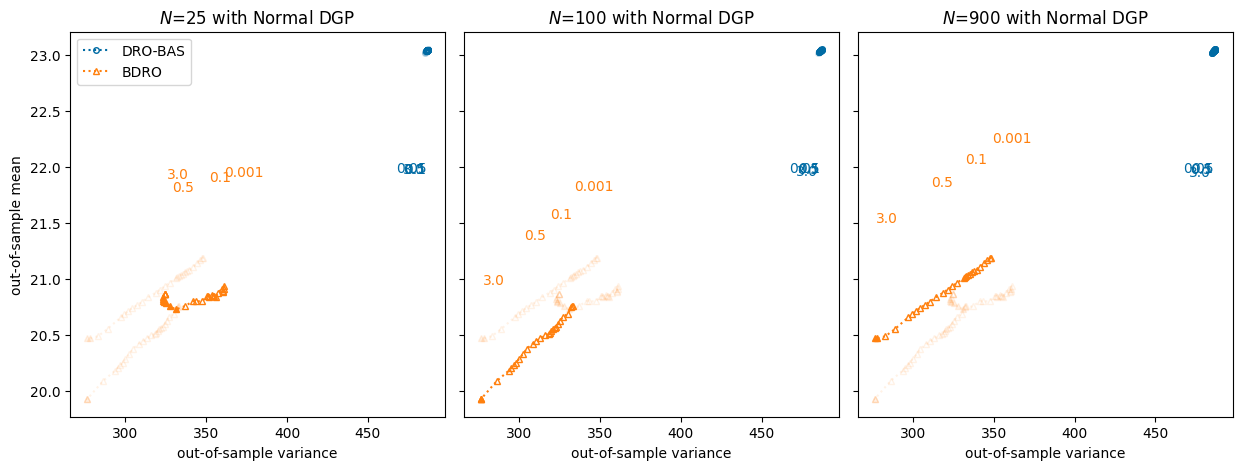

In [10]:
total_samples_sr = agg_df.index.get_level_values("num_total_samples")
TOTAL_SAMPLES = [25, 100, 900]

nrows = len(agg_df.index.get_level_values("dgp").unique())
ncols = len(TOTAL_SAMPLES)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(5*ncols, nrows*5))
fig.subplots_adjust(wspace=0.05)
# fig.suptitle(NiceNameDGP[filter_dgp], fontsize=12)

for j, total_samples in enumerate(TOTAL_SAMPLES):
    df = agg_df.loc[total_samples_sr == total_samples]
    df.loc[:, "is_minimise_pareto_front"] = is_minimise_pareto_front(df["out_of_sample_var"].values, df["out_of_sample_mean"].values)
    gb = df.groupby("dgp")

    for k in range(len(TOTAL_SAMPLES)):
        if j == k:
            alpha = 1.0
            is_labelled = True
            axes[k].set_title("$N$" + f"={total_samples} with {NiceNameDGP[filter_dgp]}")
        else:
            alpha = 0.1
            is_labelled = False
        for i, (group, group_df) in enumerate(gb):
            index_set = set(
                zip(
                    group_df.index.get_level_values("algorithm"),
                    group_df.index.get_level_values("dgp"),
                )
            )
            if k == 0:
                axes[k].set_ylabel("out-of-sample mean")
                axes[k].legend()
            axes[k].set_xlabel("out-of-sample variance")
            
            # add a new plot on the same axis for each parameter setting
            for algorithm, dgp in index_set:
                style = algorithm_style(algorithm)
                line_label = ""
                if k == 0 and j == k:
                    line_label = style.pop("label")
                else:
                    style.pop("label")
                mean_variance_plot(axes[k], group_df.loc[algorithm, dgp, :], **style, alpha=alpha, is_labelled=is_labelled, label=line_label)
# fig.savefig(f"/Users/patrick/downloads/{experiment_name}_{filter_dgp}.pdf", bbox_inches="tight")
fig.show()

## Solve time

In [6]:
results_df["is_warm_start"] = results_df.index.get_level_values("replication") == 0

# solve_time_df = results_df.groupby(["algorithm", "dgp", "num_total_samples", "is_warm_start"]).agg({"solve_time": ["mean", "std"]}).unstack(level="dgp").unstack(level="algorithm")
solve_time_df = results_df.groupby(["algorithm", "num_total_samples", "is_warm_start"]).agg({"solve_time": ["mean", "std"]}).unstack(level="algorithm").swaplevel(1,2, axis="columns")

solve_time_df


solve_time                                
algorithm                           kl_bdro kl_dro_bas   kl_bdro kl_dro_bas
                                       mean       mean       std        std
num_total_samples is_warm_start                                            
25                False            0.010642   0.012583  0.002658   0.002770
                  True             0.071467   0.030712  0.030127   0.025637
100               False            0.028822   0.025765  0.004106   0.006646
                  True             0.164283   0.037604  0.026229   0.002002
900               False            0.283199   0.467773  0.033372   0.154062
                  True             5.645570   0.291211  0.071242   0.024560
2500              False            1.174407   2.180521  0.193975   0.587862
                  True           100.959922   1.162853  0.709166   0.090489

In [7]:
print(solve_time_df.to_latex())

\begin{tabular}{llrrrr}
\toprule
 &  & \multicolumn{4}{r}{solve_time} \\
 & algorithm & kl_bdro & kl_dro_bas & kl_bdro & kl_dro_bas \\
 &  & mean & mean & std & std \\
num_total_samples & is_warm_start &  &  &  &  \\
\midrule
\multirow[t]{2}{*}{25} & False & 0.010642 & 0.012583 & 0.002658 & 0.002770 \\
 & True & 0.071467 & 0.030712 & 0.030127 & 0.025637 \\
\cline{1-6}
\multirow[t]{2}{*}{100} & False & 0.028822 & 0.025765 & 0.004106 & 0.006646 \\
 & True & 0.164283 & 0.037604 & 0.026229 & 0.002002 \\
\cline{1-6}
\multirow[t]{2}{*}{900} & False & 0.283199 & 0.467773 & 0.033372 & 0.154062 \\
 & True & 5.645570 & 0.291211 & 0.071242 & 0.024560 \\
\cline{1-6}
\multirow[t]{2}{*}{2500} & False & 1.174407 & 2.180521 & 0.193975 & 0.587862 \\
 & True & 100.959922 & 1.162853 & 0.709166 & 0.090489 \\
\cline{1-6}
\bottomrule
\end{tabular}



# Constant $G(\tau_n)$ and expected KL

In [8]:

from bayesian_dro.Bayesian_DRO_continuous import DGP_STD_TRUNCATED_NORMAL
from mis_dro.constants import NUM_REPLICATIONS, NUM_OBSERVATIONS, NUM_TEST_OBSERVATIONS
from mis_dro.dataset import sample_dgp
from mis_dro.bayes_conjugates import default_prior_params, get_posterior_params, get_log_partition_constant, derive_analytical_posterior_params
from mis_dro.newsvendor import BACKORDER_COST, HOLDING_COST, newsvendor_cost_cvxpy

def normal_newsvendor_optimal_solution(dgp_mean, dgp_std):
    return sp.stats.norm.ppf(BACKORDER_COST / (BACKORDER_COST + HOLDING_COST), dgp_mean, dgp_std)


def expected_kl_normal_gamma(dgp_mean, dgp_std, theta_params):
    mu_posterior, _, alpha_posterior, beta_posterior = theta_params
    dgp_precision = 1 / (dgp_std ** 2)
    term1 = np.log(np.sqrt(dgp_precision * (beta_posterior / alpha_posterior)))
    term2 = (dgp_std ** 2 + (dgp_mean - mu_posterior)**2) / (2 * (beta_posterior / alpha_posterior))
    return term1 + term2 - 0.5 + get_log_partition_constant("normal_gamma", theta_posterior)

dgp = "multivariate_normal"
posterior = "normal_inverse_wishart"
num_observations = NUM_OBSERVATIONS
G_constant = []             # calculate the constant G
posterior_expected_kl = []  # assuming normal DGP, what is expectation under the posterior of the KL between the DGP and the likelihood?
prior_expected_kl = []      # assuming normal DGP, what is expectation under the prior of the KL between the DGP and the likelihood?
opt_sol = normal_newsvendor_optimal_solution(25, DGP_STD_TRUNCATED_NORMAL)  # optimal solution

opt_costs = np.zeros((NUM_REPLICATIONS, NUM_TEST_OBSERVATIONS))
for j in range(NUM_REPLICATIONS):
    generator = np.random.default_rng(seed=j)
    data = sample_dgp(
        dgp, num_observations, generator=generator
    )
    data_eval = sample_dgp(
        dgp, NUM_TEST_OBSERVATIONS, contamination=0.0, generator=generator
    )
    theta_prior = default_prior_params(posterior)
    theta_posterior = get_posterior_params(posterior, data, theta_prior)
    G_constant.append(get_log_partition_constant(posterior, theta_posterior))
    posterior_expected_kl.append(expected_kl_normal_gamma(25, DGP_STD_TRUNCATED_NORMAL, theta_posterior))
    prior_expected_kl.append(expected_kl_normal_gamma(25, DGP_STD_TRUNCATED_NORMAL, theta_prior))
    opt_costs[j] = newsvendor_cost_cvxpy(opt_sol, data_eval).value
np.max(G_constant), np.var(G_constant)

ValueError: Dimension mismatch: array 'cov' is of shape (1, 1), but 'mean' is a vector of length 5.

In [ ]:
np.mean(posterior_expected_kl), np.var(posterior_expected_kl)

(0.08892539135699731, 0.0022999465683889984)

In [ ]:
np.mean(prior_expected_kl), np.var(prior_expected_kl)

(359.7442957726813, 0.0)

# Mean squared error between our solution and the solution under the DGP


In [ ]:
mean_cost = np.mean(opt_costs, axis=1)
var_cost = np.var(opt_costs, axis=1)
mean_of_means = np.mean(mean_cost)
mean_of_variances = np.mean(var_cost)
var_of_means = np.var(mean_cost)
opt_sol, mean_of_variances, var_of_means

(31.045853465832373, 809.5869569415518, 16.31412063772674)

In [ ]:
def multivariate_digamma(a: float, p: int) -> float:
    """The multivariate digamma function of dimension p

    Notes:
        [1] https://search.r-project.org/CRAN/refmans/CholWishart/html/mvdigamma.html
        [2] https://en.wikipedia.org/wiki/Multivariate_gamma_function#Derivatives
    """
    return np.sum([sp.special.digamma(a + (1.0-i)/2.0) for i in range(p)])

def get_normal_inverse_wishart_G_constant(dim: int, kappa_post: float) -> float:
    """Returns the constant G(tau, nu) for the normal-inverse-Wishart"""
    term1 = -0.5 * dim * np.log(2)
    print(term1)
    term2 = - 0.5 * multivariate_digamma(0.5 * (kappa_post - dim - 2), dim)
    print(term2)
    term3 = dim / (2 * kappa_post)
    print(term3)
    term4 = dim * 0.5 * np.log(kappa_post - dim - 2)
    print(term4)
    # term5 = 0.5 * np.log(dim)
    # print(term5)
    return term1 + term2 + term3 + term4

In [ ]:
dim = 5
_, kappa_prior, _, _ = default_prior_params("normal_inverse_wishart", dim=dim)
kappa_post = kappa_prior +  20
kappa_prior, kappa_post

(13.0, 33.0)

In [ ]:
get_normal_inverse_wishart_G_constant(dim, kappa_post)

-1.7328679513998633
-6.208643562685282
0.07575757575757576
8.145241345053705


0.2794874067261359